# Task 02 — Advanced Data Cleaning & Preprocessing
**Dataset:** [Telco Customer Churn (Kaggle)](https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
**Author:** Ateeq

This notebook builds on Task 01 (EDA) and performs advanced cleaning and
preprocessing: structural fixes, duplicate/outlier handling, feature
engineering, encoding + scaling pipeline construction, and a baseline
model sanity check to confirm the processed data is ML-ready.

## 1. Setup

In [1]:

import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.data_loader import load_raw_data, basic_info
from src.preprocessing import (
    fix_total_charges, drop_identifier_column, drop_duplicate_rows,
    detect_outliers_iqr, cap_outliers_iqr, engineer_features,
    get_feature_columns, split_data, NUMERIC_FEATURES,
)
from src.modeling import build_baseline_pipeline, evaluate_baseline

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (8, 5)

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)


def savefig(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight")

## 2. Load Raw Data

In [2]:
df = load_raw_data("data/Telco-Customer-Churn.csv")
info = basic_info(df)
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Fully duplicated rows: {info['n_duplicates']}")
print(f"Duplicate customerIDs: {info['n_duplicate_customer_ids']}")
df.head()

Shape: 7043 rows, 21 columns
Fully duplicated rows: 0
Duplicate customerIDs: 0


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Structural Cleaning

`TotalCharges` is loaded as text because 11 rows contain blank strings.
All 11 belong to customers with `tenure == 0` (no billing history yet),
so this is a structural, explainable pattern - imputed with `0`.

In [3]:
missing_before = pd.to_numeric(df["TotalCharges"], errors="coerce").isna().sum()
print(f"Non-numeric TotalCharges rows: {missing_before}")

df = fix_total_charges(df)
df, n_dropped = drop_duplicate_rows(df)
print(f"Duplicate rows dropped: {n_dropped}")
df = drop_identifier_column(df)
print(f"Shape after structural cleaning: {df.shape}")

Non-numeric TotalCharges rows: 11
Duplicate rows dropped: 0
Shape after structural cleaning: (7043, 20)


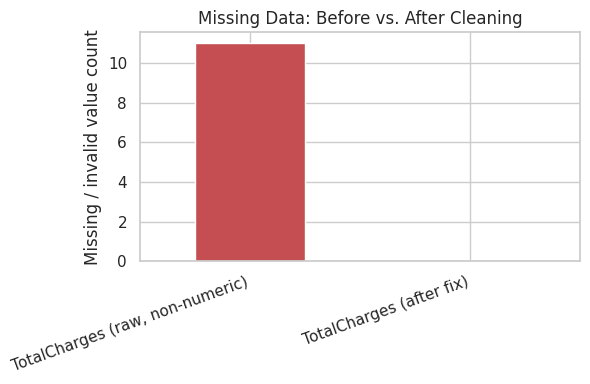

In [4]:
plt.figure(figsize=(6, 4))
missing_counts = pd.Series({"TotalCharges (raw, non-numeric)": missing_before, "TotalCharges (after fix)": 0})
missing_counts.plot(kind="bar", color=["#c44e52", "#4c72b0"])
plt.ylabel("Missing / invalid value count")
plt.title("Missing Data: Before vs. After Cleaning")
plt.xticks(rotation=20, ha="right")
savefig("01_missing_data_before_after")
plt.show()

## 4. Outlier Detection & Treatment

Numeric features are checked for outliers using the IQR rule
(1.5 x IQR beyond Q1/Q3). Any outliers found are capped (winsorized)
rather than dropped, to preserve sample size.

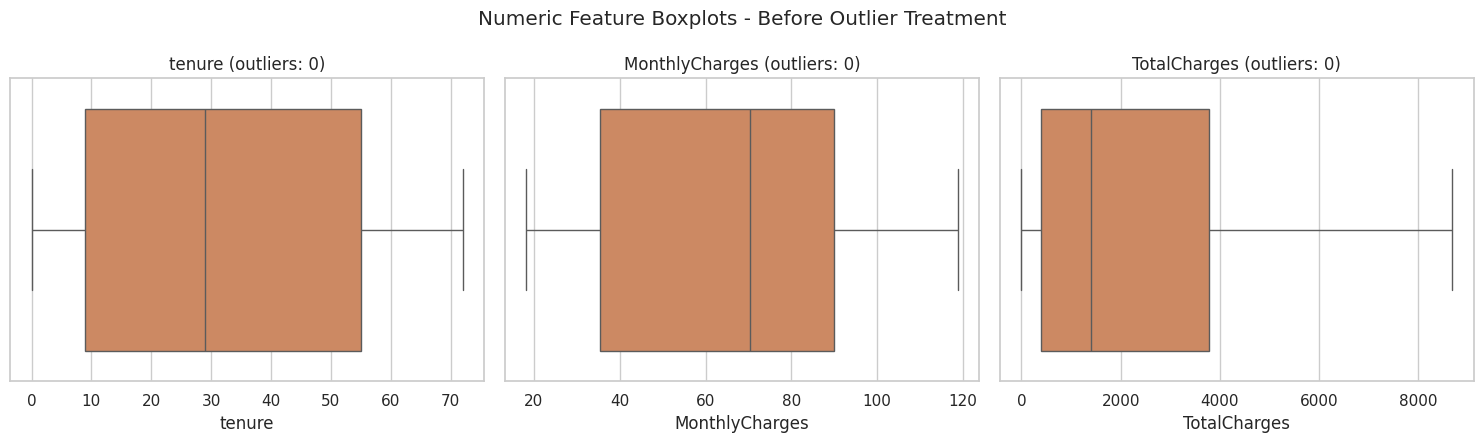

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.boxplot(x=df[col], ax=ax, color="#dd8452")
    n_out = detect_outliers_iqr(df, col).sum()
    ax.set_title(f"{col} (outliers: {n_out})")
plt.suptitle("Numeric Feature Boxplots - Before Outlier Treatment")
savefig("02_boxplots_before_outlier_treatment")
plt.show()

IQR outlier counts: {'tenure': 0, 'MonthlyCharges': 0, 'TotalCharges': 0}


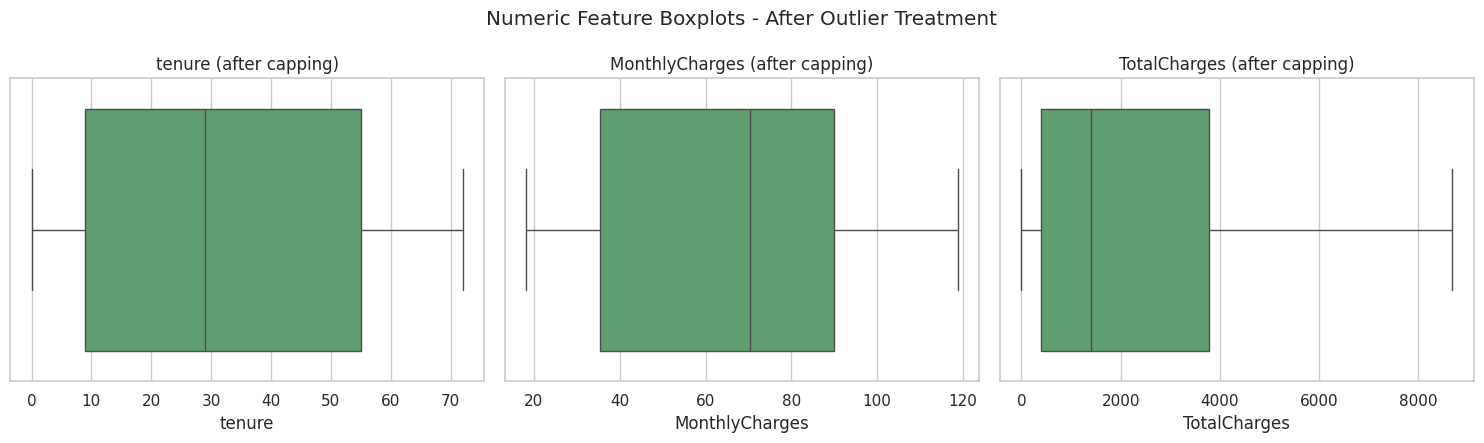

In [6]:
outlier_counts = {col: int(detect_outliers_iqr(df, col).sum()) for col in NUMERIC_FEATURES}
print("IQR outlier counts:", outlier_counts)

for col in NUMERIC_FEATURES:
    df = cap_outliers_iqr(df, col)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, NUMERIC_FEATURES):
    sns.boxplot(x=df[col], ax=ax, color="#55a868")
    ax.set_title(f"{col} (after capping)")
plt.suptitle("Numeric Feature Boxplots - After Outlier Treatment")
savefig("03_boxplots_after_outlier_treatment")
plt.show()

**Result:** the Telco numeric features (tenure, MonthlyCharges,
TotalCharges) are naturally bounded (contracts run 0-72 months, charges
have realistic caps), so the IQR rule finds **0 outliers** in all three
columns. The capping step is still included as a defensive, reusable part
of the pipeline in case future data (e.g. a production feed) contains
extreme values.

## 5. Feature Engineering

New features are derived to summarize customer behaviour more richly
than the raw columns alone:
- `tenure_group`: binned tenure (0-12, 13-24, 25-48, 49-60, 61-72 months)
- `num_services`: count of subscribed add-on/utility services
- `avg_monthly_spend`: TotalCharges normalised by tenure
- `has_internet`: whether the customer has any internet service

In [7]:
df = engineer_features(df)
df[["tenure", "tenure_group", "num_services", "avg_monthly_spend", "has_internet"]].head(8)

,tenure,tenure_group,num_services,avg_monthly_spend,has_internet
0,1,0-12,2,29.850000,1
1,34,25-48,4,55.573529,1
2,2,0-12,4,54.075000,1
3,45,25-48,4,40.905556,1
4,2,0-12,2,75.825000,1
5,8,0-12,6,102.562500,1
6,22,13-24,5,88.609091,1
7,10,0-12,2,30.190000,1


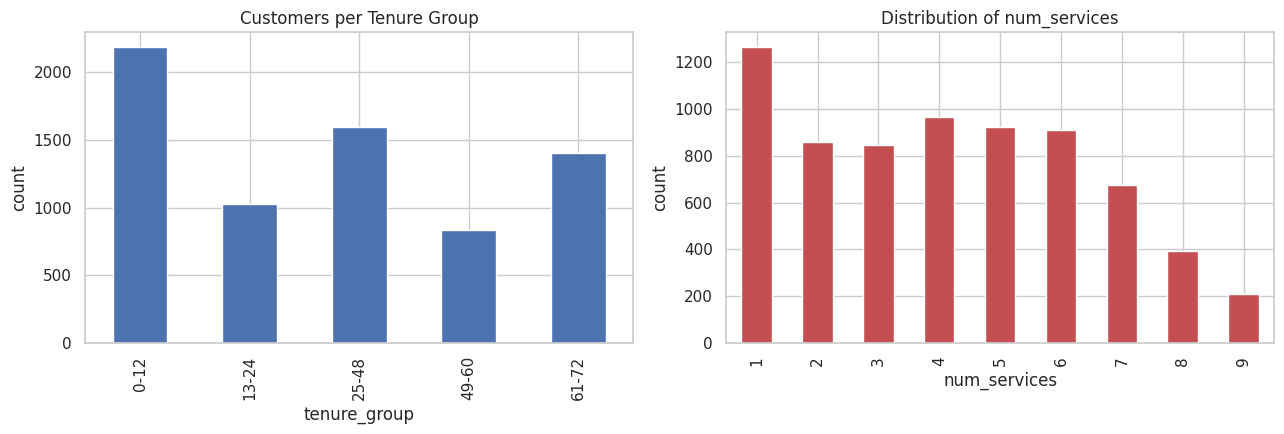

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df["tenure_group"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="#4c72b0")
axes[0].set_title("Customers per Tenure Group")
axes[0].set_ylabel("count")

df["num_services"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#c44e52")
axes[1].set_title("Distribution of num_services")
axes[1].set_ylabel("count")
savefig("04_engineered_feature_distributions")
plt.show()

## 6. Correlation Check (Engineered Numeric Features)

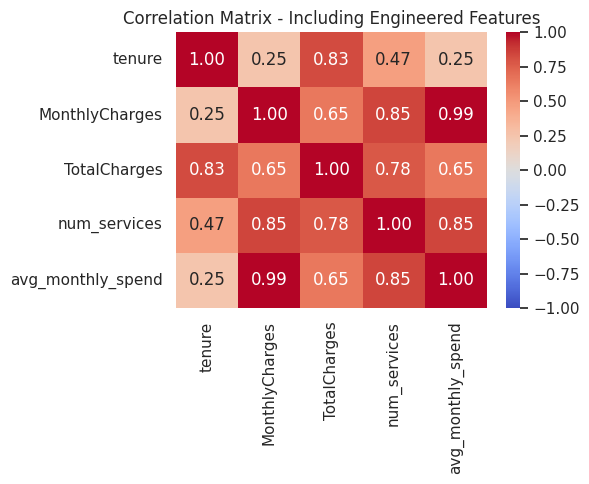

In [9]:
corr_cols = ["tenure", "MonthlyCharges", "TotalCharges", "num_services", "avg_monthly_spend"]
plt.figure(figsize=(6, 5))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix - Including Engineered Features")
savefig("05_correlation_engineered_features")
plt.show()

## 7. Encoding & Scaling Pipeline

Categorical features are one-hot encoded and numeric features are
standard-scaled, both wrapped in a single `sklearn.compose.ColumnTransformer`
so the exact same transformation can be reapplied to new data at
inference time without leakage.

In [10]:
numeric_cols, categorical_cols = get_feature_columns(df)
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

X_train, X_test, y_train, y_test = split_data(df)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}, Test churn rate: {y_test.mean():.3f}")

Numeric columns (5): ['tenure', 'MonthlyCharges', 'TotalCharges', 'num_services', 'avg_monthly_spend']
Categorical columns (18): ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group', 'has_internet']
Train shape: (5634, 23), Test shape: (1409, 23)
Train churn rate: 0.265, Test churn rate: 0.265


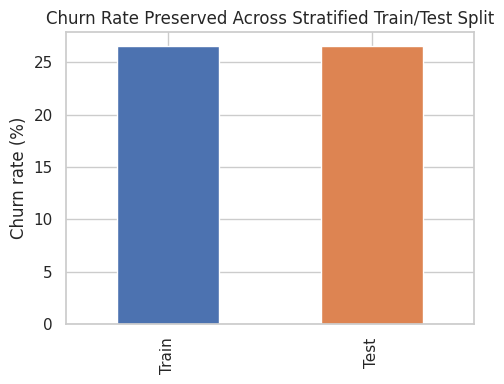

In [11]:
plt.figure(figsize=(5, 4))
pd.Series({"Train": y_train.mean() * 100, "Test": y_test.mean() * 100}).plot(kind="bar", color=["#4c72b0", "#dd8452"])
plt.ylabel("Churn rate (%)")
plt.title("Churn Rate Preserved Across Stratified Train/Test Split")
savefig("06_train_test_churn_balance")
plt.show()

## 8. Baseline Model Sanity Check

A simple Logistic Regression is trained purely to confirm the cleaned,
engineered, encoded, and scaled data is usable for machine learning.
Full model development, tuning, and comparison are out of scope for this
task and are deferred to a later stage of the internship.

In [12]:
pipeline = build_baseline_pipeline(numeric_cols, categorical_cols)
metrics = evaluate_baseline(pipeline, X_train, y_train, X_test, y_test)
print("Baseline Logistic Regression metrics on held-out test set:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

Baseline Logistic Regression metrics on held-out test set:
  accuracy: 0.7999
  precision: 0.6554
  recall: 0.5187
  f1: 0.5791
  roc_auc: 0.8426


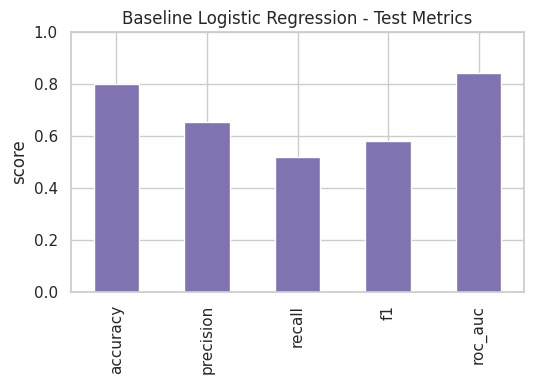

In [13]:
plt.figure(figsize=(5.5, 4))
pd.Series(metrics).plot(kind="bar", color="#8172b2")
plt.ylim(0, 1)
plt.title("Baseline Logistic Regression - Test Metrics")
plt.ylabel("score")
savefig("07_baseline_model_metrics")
plt.show()

## 9. Export the Cleaned & Engineered Dataset

In [14]:
os.makedirs("data/processed", exist_ok=True)
out_path = "data/processed/telco_cleaned_engineered.csv"
df.to_csv(out_path, index=False)
print(f"Saved cleaned & engineered dataset to {out_path} - shape {df.shape}")

Saved cleaned & engineered dataset to data/processed/telco_cleaned_engineered.csv - shape (7043, 24)


## 10. Summary

- Fixed the `TotalCharges` type issue and confirmed 0 duplicate rows.
- Ran IQR-based outlier detection on all numeric features (0 outliers found;
  capping logic included defensively for future data).
- Engineered 4 new features (`tenure_group`, `num_services`,
  `avg_monthly_spend`, `has_internet`).
- Built a reusable `ColumnTransformer` preprocessing pipeline (scaling +
  one-hot encoding) and a stratified train/test split.
- Verified the processed data is ML-ready with a baseline Logistic
  Regression (ROC-AUC ≈ 0.84 on the held-out test set).
- Exported the final cleaned/engineered dataset to `data/processed/`.